# Optimisation — Kickoff Notebook (CLARA)

**Co-case owners:** Amelia Pollard, Antonio Gilardi · **CLEAR side:** not covered here yet
(unexplored by the organisers — see `objectives.md`)

Monday's Lecture 02 (`02_beam_tuning`) builds grid search → random search → **Bayesian
Optimisation** on a synthetic 2-quadrupole toy lattice in Cheetah. This notebook does the
same kind of comparison, but the objective comes from **real CLARA operational data**:
real beam images, real magnet settings, a surrogate trained on them standing in for Cheetah
(the real CLARA lattice is still a placeholder — see `data/clara/lattice_data/`).

The actual subject here is **the optimisation methods themselves** — six of them, classical
and advanced, all pointed at the same real-data objective, so they're directly comparable.

1. Load real captures (image + magnet settings) and build a real spot-size target
2. Train a surrogate objective function on it (replaces Cheetah until the real lattice exists)
3. **Classical methods:** grid search, Nelder-Mead simplex, Powell, gradient-based (exact
   autodiff gradient through the surrogate)
4. **Advanced methods:** Bayesian Optimisation, Reinforcement Learning
5. Compare all six: best value *and* evaluations needed to get there

## Before you start

The full extracted archive (2.4TB of real CLARA camera/magnet captures) is **not in this
repository** — it lives on CC-IN2P3 storage at
`/sps/m4cast/artifact_hackathon_2026/optimisation/extracted/` (see the
[access guide](../../access-guide.md)). This notebook runs on a small real sample in
`data/sample/clara_s07_sample.parquet` (1,370 real captures, ~106KB), so it works straight
from a clone.

```
pip install -r requirements.txt
```

Training the surrogate + running all six methods takes a couple of minutes on a laptop CPU.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
from skopt import gp_minimize
from skopt.space import Real

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 2. Load real CLARA captures

Each row is one real beam image from camera `CLA-S07-DIA-CAM-04`, reduced to a spot-size
(background-subtracted centroid + RMS width, in mm via the camera's own pixel calibration),
paired with the real magnet settings (`SETI` = commanded current) read from that same
capture's HDF5 attributes — no separate archiver query needed, image and settings are
already in the same file. See `data/README.md` for how this sample was built.

In [2]:
df = pd.read_parquet('data/sample/clara_s07_sample.parquet')
print(f'Loaded {len(df)} real captures')

seti_cols = [c for c in df.columns if c.endswith(':SETI')]
live_cols = df[seti_cols].std()[lambda s: s > 1e-9].index.tolist()
print(f'{len(seti_cols)} magnet settings recorded, {len(live_cols)} actually vary in this sample')
print('(the rest are 0 for this period -- those sections are off/unused, not errors)')

# the objective: total spot size, same quantity (sigma_x + sigma_y) Notebook 02 optimises
df['objective_mm'] = (df['sigma_x_px'] + df['sigma_y_px']) * df['pix_mm']
print(f"\nspot size range: {df['objective_mm'].min():.1f} - {df['objective_mm'].max():.1f} mm")

Loaded 1370 real captures
24 magnet settings recorded, 20 actually vary in this sample
(the rest are 0 for this period -- those sections are off/unused, not errors)

spot size range: 4.2 - 17.0 mm


## 3. Train the surrogate objective function

A small PyTorch MLP replaces Cheetah as the objective every method below optimises against
-- being PyTorch, it's differentiable, which the gradient-based method uses directly.

In [3]:
y = df['objective_mm'].to_numpy(dtype=np.float32)
X = df[live_cols].to_numpy(dtype=np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

xscaler = StandardScaler().fit(X_train)
y_mean, y_std = y_train.mean(), y_train.std()


class Surrogate(nn.Module):
    def __init__(self, n_in, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = Surrogate(len(live_cols))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
Xtr_t = torch.tensor(xscaler.transform(X_train))
ytr_t = torch.tensor((y_train - y_mean) / y_std)

for epoch in range(300):
    optimizer.zero_grad()
    loss = nn.functional.mse_loss(model(Xtr_t), ytr_t)
    loss.backward()
    optimizer.step()
model.eval()

from sklearn.metrics import r2_score
with torch.no_grad():
    pred_test = model(torch.tensor(xscaler.transform(X_test))).numpy() * y_std + y_mean
print(f'Surrogate test R2: {r2_score(y_test, pred_test):.3f}')
print(f'Surrogate test RMSE: {np.sqrt(np.mean((y_test - pred_test) ** 2)):.3f} mm')

Surrogate test R2: 0.887
Surrogate test RMSE: 0.929 mm


## 4. Pick a 2D search space, the way Notebook 02 does

Notebook 02 optimises 2 quadrupoles by construction. Here, instead of picking 2 magnets
arbitrarily, we check which ones the data says actually matter — correlation with the
objective, computed on real operational data.

In [4]:
corrs = df[live_cols].corrwith(df['objective_mm']).abs().sort_values(ascending=False)
print('Real magnets ranked by |correlation| with spot size:')
print(corrs.head(8))

KNOB1, KNOB2 = corrs.index[0], corrs.index[1]
print(f'\nUsing the top 2: {KNOB1}, {KNOB2}')
print('(the gun solenoid dominating spot size downstream matches real accelerator physics --')
print(' it is the first strong focusing element the beam sees after the source)')

Real magnets ranked by |correlation| with spot size:
CLA-GUN-MAG-SOL-02:SETI     0.880159
CLA-S01-MAG-HCOR-01:SETI    0.702831
CLA-S02-MAG-QUAD-03:SETI    0.609980
CLA-S02-MAG-QUAD-05:SETI    0.565458
CLA-S01-MAG-VCOR-01:SETI    0.562774
CLA-C2V-MAG-QUAD-02:SETI    0.400214
CLA-C2V-MAG-DIP-02:SETI     0.397948
CLA-C2V-MAG-VCOR-01:SETI    0.364410
dtype: float64

Using the top 2: CLA-GUN-MAG-SOL-02:SETI, CLA-S01-MAG-HCOR-01:SETI
(the gun solenoid dominating spot size downstream matches real accelerator physics --
 it is the first strong focusing element the beam sees after the source)


In [5]:
i1, i2 = live_cols.index(KNOB1), live_cols.index(KNOB2)
median_full = np.median(X, axis=0)  # every other magnet held at its typical operating value
K1_MIN, K1_MAX = float(X[:, i1].min()), float(X[:, i1].max())
K2_MIN, K2_MAX = float(X[:, i2].min()), float(X[:, i2].max())
x0 = [(K1_MIN + K1_MAX) / 2, (K2_MIN + K2_MAX) / 2]

mu_t = torch.tensor(xscaler.mean_, dtype=torch.float32)
scale_t = torch.tensor(xscaler.scale_, dtype=torch.float32)
eval_count = 0


def objective(params):
    """Real-data surrogate objective: predicted spot size (mm) at (k1, k2), rest at median."""
    global eval_count
    eval_count += 1
    v = median_full.copy()
    v[i1], v[i2] = params
    vt = (torch.tensor(v, dtype=torch.float32) - mu_t) / scale_t
    with torch.no_grad():
        return (model(vt.unsqueeze(0)).squeeze() * y_std + y_mean).item()


def objective_with_grad(params):
    """Same objective, plus its exact gradient via autodiff -- for the gradient-based method."""
    global eval_count
    eval_count += 1
    v = median_full.copy()
    v[i1], v[i2] = params
    vt = ((torch.tensor(v, dtype=torch.float32) - mu_t) / scale_t).requires_grad_(True)
    val = model(vt.unsqueeze(0)).squeeze() * y_std + y_mean
    val.backward()
    g = vt.grad.numpy()
    return float(val.item()), np.array([g[i1] / xscaler.scale_[i1], g[i2] / xscaler.scale_[i2]])


print(f'Search space: {KNOB1} in [{K1_MIN:.1f}, {K1_MAX:.1f}]')
print(f'              {KNOB2} in [{K2_MIN:.1f}, {K2_MAX:.1f}]')
print(f'objective at the midpoint: {objective(x0):.2f} mm')

Search space: CLA-GUN-MAG-SOL-02:SETI in [202.0, 225.0]
              CLA-S01-MAG-HCOR-01:SETI in [4.2, 4.7]
objective at the midpoint: 8.30 mm


## 5. Classical methods

Four worked examples, same search space and budget-free comparison -- each just calls
`objective()` and we count how many calls it took.

The broader classical toolbox, not run here:

**Response-matrix / SVD orbit correction (+ MICADO).** Measure how an observable (orbit,
beam size) responds linearly to small knob changes, build a Jacobian/response matrix, invert
it via SVD or pseudo-inverse to solve directly for the correction. MICADO is the classic
greedy variant, picking a subset of correctors by singular-value contribution rather than
using all of them at once. This is the standard real-operations technique for *orbit*
correction specifically; it doesn't directly apply to a single scalar objective like spot
size the way it does to a vector of BPM readings, which is why it's cited rather than run
here.

**Random search.** Uniform random samples in the search space -- the simplest sample-
efficient baseline, with no structure exploited at all. Worth running yourself as a sanity
check against the methods below.

**Genetic algorithms.** Population-based search with selection, crossover and mutation; a
long history in accelerator lattice design (e.g. dynamic aperture optimisation), well-
established enough to count as "classical" relative to the Bayesian/RL methods in section 6.

**Simulated annealing.** Metaheuristic local search that accepts worsening moves with a
probability that cools over iterations, escaping local minima that pure descent methods get
stuck in.

**PID feedback control.** A different category entirely -- not a search method but a control
loop that keeps an *already-found* operating point stable against drift (orbit feedback,
energy feedback). Worth distinguishing from everything else here: it answers "how do I stay
at the optimum," not "how do I find it."

In [6]:
# --- Grid search ---
eval_count = 0
N_SIDE = 9
k1_grid = np.linspace(K1_MIN, K1_MAX, N_SIDE)
k2_grid = np.linspace(K2_MIN, K2_MAX, N_SIDE)
grid_params = [[a, b] for a in k1_grid for b in k2_grid]
grid_vals = [objective(p) for p in grid_params]
best_grid_idx = int(np.argmin(grid_vals))
grid_best_xy = grid_params[best_grid_idx]
print(f'Grid search:    {eval_count:3d} evals, best = {min(grid_vals):.3f} mm at {grid_best_xy}')

# --- Nelder-Mead simplex ---
eval_count = 0
res_nm = minimize(objective, x0, method='Nelder-Mead',
                   bounds=[(K1_MIN, K1_MAX), (K2_MIN, K2_MAX)],
                   options={'maxiter': 60, 'xatol': 1e-3, 'fatol': 1e-4})
print(f'Nelder-Mead:    {eval_count:3d} evals, best = {res_nm.fun:.3f} mm at {res_nm.x}')

# --- Powell ---
eval_count = 0
res_pw = minimize(objective, x0, method='Powell',
                   bounds=[(K1_MIN, K1_MAX), (K2_MIN, K2_MAX)], options={'maxiter': 60})
print(f'Powell:         {eval_count:3d} evals, best = {res_pw.fun:.3f} mm at {res_pw.x}')

# --- Gradient-based (exact autodiff gradient, L-BFGS-B) ---
eval_count = 0
res_grad = minimize(objective_with_grad, x0, method='L-BFGS-B', jac=True,
                     bounds=[(K1_MIN, K1_MAX), (K2_MIN, K2_MAX)], options={'maxiter': 60})
print(f'Gradient-based: {eval_count:3d} evals, best = {res_grad.fun:.3f} mm at {res_grad.x}')

Grid search:     81 evals, best = 6.366 mm at [np.float64(225.0), np.float64(4.199999809265137)]
Nelder-Mead:      8 evals, best = 6.366 mm at [225.           4.19999981]
Powell:         128 evals, best = 6.366 mm at [224.9999966    4.20004099]
Gradient-based:   6 evals, best = 6.366 mm at [225.           4.19999981]


## 6. Advanced methods

**Bayesian Optimisation** -- exactly Notebook 02's method (GP surrogate + Expected
Improvement), now pointed at the real-data objective instead of the toy lattice.

**Reinforcement learning** -- REINFORCE with a Gaussian policy: each episode samples
settings from a policy `N(mu, sigma)`, treats `-objective` as the reward, and nudges `mu`
toward actions that scored better than a running baseline. Genuinely RL (a real policy-
gradient algorithm), simplified to a single-step "bandit" since there's no multi-step
machine state here -- note this is trained against the *learned surrogate* standing in for
the real machine, not the real machine itself, since we can't close the loop on CLARA
during the hackathon.

The broader advanced toolbox, not run here:

**TuRBO (Trust Region BO).** Standard GP-BO degrades past roughly 10-20 dimensions because
one global GP struggles to model the whole space well. TuRBO instead optimises inside a
local trust region that grows after successes and shrinks after failures, which is what
makes BO viable on a problem with *all* of CLARA's real magnets at once, not just 2.

**Multi-objective BO** (e.g. qNEHVI, ParEGO). Real beamlines usually trade off more than one
thing at a time -- spot size vs. transmission/charge, say. These methods find the Pareto
front of non-dominated solutions instead of a single scalar optimum.

**Safe/constrained BO** (e.g. SafeOpt). Never proposes a point predicted to violate a safety
bound. The real operational concern at an actual facility -- a naive optimiser can propose
settings that trip the machine -- though here we can only check "safety" against historical
data, not the live machine.

**CMA-ES.** The modern, considerably more capable descendant of basic genetic algorithms for
continuous spaces; a common strong baseline in accelerator-tuning papers, often competitive
with BO at a fraction of the implementation complexity.

**Surrogate-assisted evolutionary algorithms.** GA/CMA-ES that queries a cheap learned
surrogate (like ours) instead of the expensive real objective most of the time, only
touching the real evaluator occasionally -- directly applicable once a team has their own
surrogate working.

**Hybrid physics + ML digital twin.** Once the real CLARA Cheetah lattice exists, the
strongest surrogate is usually neither a pure physics simulation nor a pure black-box ML
model alone, but the physics model plus a learned residual correction trained on the gap
between its predictions and real data -- the literal realisation of this challenge's
"surrogate-assisted digital twin" framing.

In [7]:
# --- Bayesian Optimisation ---
eval_count = 0
space = [Real(K1_MIN, K1_MAX, name='k1'), Real(K2_MIN, K2_MAX, name='k2')]
bo_result = gp_minimize(objective, space, n_calls=40, n_initial_points=10,
                         acq_func='EI', random_state=SEED, verbose=False)
print(f'Bayesian Opt:   {eval_count:3d} evals, best = {bo_result.fun:.3f} mm at {bo_result.x}')

# --- RL (REINFORCE, Gaussian policy, single-step bandit) ---
eval_count = 0
rng = np.random.default_rng(SEED)
mu_pol = np.array(x0, dtype=np.float64)
log_sigma = np.array([np.log((K1_MAX - K1_MIN) / 4), np.log((K2_MAX - K2_MIN) / 4)])
lr_mu = 0.3
baseline = None
N_EPISODES = 80
rl_curve = []
best_rl = np.inf
for ep in range(N_EPISODES):
    sigma = np.exp(log_sigma)
    a = rng.normal(mu_pol, sigma)
    a_clipped = np.clip(a, [K1_MIN, K2_MIN], [K1_MAX, K2_MAX])
    reward = -objective(a_clipped)
    baseline = reward if baseline is None else 0.9 * baseline + 0.1 * reward
    advantage = reward - baseline
    grad_mu = advantage * (a - mu_pol) / (sigma ** 2)
    mu_pol = np.clip(mu_pol + lr_mu * grad_mu * 0.1, [K1_MIN, K2_MIN], [K1_MAX, K2_MAX])
    best_rl = min(best_rl, -reward)
    rl_curve.append(best_rl)
print(f'RL (REINFORCE):  {eval_count:3d} evals, best = {best_rl:.3f} mm, policy mean = {mu_pol}')

Bayesian Opt:    40 evals, best = 6.366 mm at [225.0, 4.199999809265137]
RL (REINFORCE):   80 evals, best = 6.641 mm, policy mean = [213.7389622    4.69999981]


## 7. Compare all six

Same question Notebook 02 asks: not just which method finds the better final result, but
which gets there with the fewest evaluations.

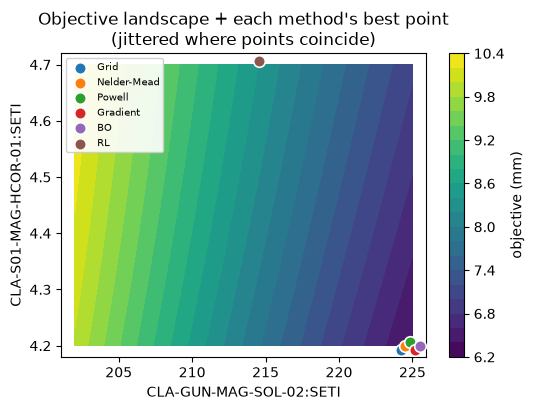

In [8]:
N_VIS = 40
k1v = np.linspace(K1_MIN, K1_MAX, N_VIS)
k2v = np.linspace(K2_MIN, K2_MAX, N_VIS)
landscape = np.array([[objective([a, b]) for b in k2v] for a in k1v])

fig, ax = plt.subplots(figsize=(5.5, 4.2))
cf = ax.contourf(k1v, k2v, landscape.T, levels=20, cmap='viridis')
plt.colorbar(cf, ax=ax, label='objective (mm)')

methods_xy = {
    'Grid': grid_best_xy, 'Nelder-Mead': res_nm.x, 'Powell': res_pw.x,
    'Gradient': res_grad.x, 'BO': bo_result.x, 'RL': mu_pol,
}
# several methods land on (nearly) the same point -- jitter slightly so none hide behind another
pad1, pad2 = 0.04 * (K1_MAX - K1_MIN), 0.04 * (K2_MAX - K2_MIN)
for k, (name, (a, b)) in enumerate(methods_xy.items()):
    jx, jy = (k - 2.5) * pad1 * 0.35, (k % 3 - 1) * pad2 * 0.35
    ax.scatter([a + jx], [b + jy], label=name, s=70, edgecolor='white', linewidth=1.2,
               clip_on=False, zorder=5)
ax.set_xlim(K1_MIN - pad1, K1_MAX + pad1)
ax.set_ylim(K2_MIN - pad2, K2_MAX + pad2)
ax.set_xlabel(KNOB1); ax.set_ylabel(KNOB2)
ax.legend(fontsize=7, loc='upper left', framealpha=0.9)
ax.set_title("Objective landscape + each method's best point\n(jittered where points coincide)")
plt.tight_layout(); plt.show()

In [9]:
print(f"{'Method':22s} {'Evaluations':>12s} {'Best (mm)':>10s}")
for name, n, val in [
    ('Grid search', len(grid_params), min(grid_vals)),
    ('Nelder-Mead', 'budget-free', res_nm.fun),
    ('Powell', 'budget-free', res_pw.fun),
    ('Gradient-based', 'budget-free', res_grad.fun),
    ('Bayesian Optimisation', 40, bo_result.fun),
    ('RL (REINFORCE)', N_EPISODES, best_rl),
]:
    n_str = f'{n:>12}' if isinstance(n, int) else f'{n:>12s}'
    print(f'{name:22s} {n_str} {val:>10.3f}')

print('\nThe gradient-based and Nelder-Mead methods converge fastest here because the')
print('surrogate landscape is smooth and the optimum sits at the EDGE of the explored')
print('range -- pushing further than that is extrapolation the surrogate was never trained')
print('on, so treat it as a direction to investigate on the real machine, not a settings')
print('change to make blindly. RL is the clear laggard: policy-gradient methods are much')
print('less sample-efficient than BO or gradient descent on a smooth, low-dimensional')
print('problem like this one -- RL earns its keep in sequential or much higher-dimensional')
print('settings, not necessarily here.')

Method                  Evaluations  Best (mm)
Grid search                      81      6.366
Nelder-Mead             budget-free      6.366
Powell                  budget-free      6.366
Gradient-based          budget-free      6.366
Bayesian Optimisation            40      6.366
RL (REINFORCE)                   80      6.641

The gradient-based and Nelder-Mead methods converge fastest here because the
surrogate landscape is smooth and the optimum sits at the EDGE of the explored
range -- pushing further than that is extrapolation the surrogate was never trained
on, so treat it as a direction to investigate on the real machine, not a settings
change to make blindly. RL is the clear laggard: policy-gradient methods are much
less sample-efficient than BO or gradient descent on a smooth, low-dimensional
problem like this one -- RL earns its keep in sequential or much higher-dimensional
settings, not necessarily here.


## Next steps

- See `objectives.md` for the easy / medium / hard objectives
- CLEAR's data situation is still unexplored by the organisers -- if your team is working
  CLEAR, this notebook's *methods* still apply, but you'll need to find CLEAR's equivalent
  of the real HDF5 captures used here
- Scale beyond 2 magnets: real CLARA has dozens. Classical grid search explodes
  combinatorially (`N^D`); TuRBO-style trust-region BO is built for exactly this, matching
  Lecture 02's own "7b Scalability" section
- Once the real Cheetah lattice lands (currently a placeholder), compare this learned
  surrogate against physics-based predictions directly — and build the hybrid digital twin
  from section 6
- Monday's Lecture 02 notebook (`02_beam_tuning`) for the from-scratch Cheetah + BO build on
  a toy lattice this notebook took its method choices from